# Gaussian priors in infinite dimensions

In this notebook we show how to construct PDE-based priors that lead to well-posed Bayesian
inverse problems in infinite dimensions. Specifically, we consider a Gaussian prior
$\mu_{\rm prior} \sim \mathcal{N}( m_{\rm prior}, \mathcal{C}_{\rm prior} )$, where the
covariance operator $\mathcal{C}_{\rm prior}$ is defined as the inverse of an elliptic
differential operator, i.e.

$$ \mathcal{C}_{\rm prior} = \left( \delta I - \gamma \Delta \right)^{-\alpha}, $$

equipped with homogeneous Neumann, Dirichlet or Robin boundary conditions, and
$m_{\rm prior} \in H^{\frac{\alpha}{2}}(\Omega)$, where $\Omega \subset \mathbb{R}^d$.

The parameter $\alpha > \frac{d}{2}$ controls the smoothness of the random field and ensures
that $\mathcal{C}_{\rm prior}$ is a trace class operator (i.e., the infinite sum of the
eigenvalues of $\mathcal{C}_{\rm prior}$ is finite). That $\mathcal{C}_{\rm prior}$ is trace
class is extremely important, as it guarantees that the pointwise variance of the samples is
finite. (Recall that for a Gaussian random field
$E \left[\int_{\Omega}(m - m_{\rm prior})^2\,dx\right] = \operatorname{trace}(\mathcal{C}_{\rm prior})$.)

The parameters $\delta>0$, $\gamma>0$ can be constant in $\Omega$ (in this case the prior is
called stationary) or spatially varying.

It can be shown that, in the case of the BiLaplacian prior ($\alpha=2$) in $d$ spatial
dimensions, the relationship between the PDE coefficients $\gamma$ and $\delta$ and the
desired marginal variance $\sigma^2$ and correlation length $\rho$ is

$$ \gamma = \frac{1}{s}, \quad \delta = \frac{\kappa^2}{s}, $$

where

$$ \nu = 2 - \frac{d}{2}, \quad \kappa = \frac{\sqrt{8\nu}}{\rho}, \text{ and } s = \sigma\kappa^\nu\sqrt{\frac{(4\pi)^{d/2}}{\Gamma(\nu)}}.$$

The above formulae are implemented in `hm.BiLaplacianComputeCoefficients`, which computes the
coefficients `gamma` and `delta` of the BiLaplacian prior ($\alpha=2$) from the desired
marginal variance $\sigma^2$ and correlation length $\rho$.

## Import dependencies

In [1]:
import math
import os
import sys

sys.path.insert(0, os.environ.get("HIPPYMFEM_BASE_DIR", os.path.abspath("..")))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

from mpi4py import MPI
import mfem.par as mfem

import hippymfem as hm
from hippymfem import nb

mfem.Hypre.Init()
comm = MPI.COMM_WORLD

## Plot the marginal variance and correlation structure at a given point

The covariance between the field at a point $x_0$ and everywhere else is the prior
covariance applied to a point source at $x_0$. The observation operator of a single point
supplies the point source ($B^T e$), and one application of $R^{-1}$, the prior covariance,
gives the covariance function $c(\cdot, x_0)$; its value at $x_0$ is the marginal variance
there. The marginal variance everywhere is the diagonal of the covariance, computed exactly
here: the meshes are small, and it takes two solves per degree of freedom.

In [2]:
def anisotropic_tensor(theta0, theta1, alpha):
    sa, ca = math.sin(alpha), math.cos(alpha)
    return np.array([[theta0 * sa**2 + theta1 * ca**2, (theta0 - theta1) * sa * ca],
                     [(theta0 - theta1) * sa * ca, theta0 * ca**2 + theta1 * sa**2]])


def make_prior(Vh, sigma2, rho, degree=2, anisotropic=False, use_robin=True,
               theta0=2.0, theta1=0.5, alpha=math.pi / 4):
    ndim = Vh.mesh.Dimension()
    gamma, delta = hm.BiLaplacianComputeCoefficients(sigma2, rho, ndim)
    if degree == 1:
        return hm.LaplacianPrior(Vh, gamma, delta, solver_type="lu")
    Theta = anisotropic_tensor(theta0, theta1, alpha) if anisotropic else None
    return hm.BiLaplacianPrior(Vh, gamma, delta, Theta=Theta, robin_bc=use_robin,
                               solver_type="lu")


def correlationStructure(prior, Vh, center):
    B = hm.assemblePointwiseObservation(Vh, np.atleast_2d(center))
    e = B.createVecLeft()
    e.set(1.0)
    rhs = Vh.vector()
    B.multTranspose(e, rhs)
    corrStruct = Vh.vector()
    prior.Rsolver.solve(corrStruct, rhs)
    return corrStruct


def makeCorrelationPlots(mesh, sigma2, rho, coords, degree=2, cmap="viridis", **kwargs):
    ndim = mesh.Dimension()
    Vh = hm.FunctionSpace.H1(mesh, 1)
    prior = make_prior(Vh, sigma2, rho, degree=degree, **kwargs)

    pointwise_variance = prior.pointwise_variance(method="Exact")
    correlation_struc = correlationStructure(prior, Vh, coords)

    print("Prescribed marginal variance: ", sigma2)
    print("Actual marginal variance:", correlation_struc.norm("linf"))

    if ndim == 1:
        fig, axes = plt.subplots(1, 2, figsize=[15, 5])
        nb.plot(Vh, pointwise_variance, ax=axes[0], mytitle="Marginal variance")
        nb.plot(Vh, correlation_struc, ax=axes[1], mytitle="Correlation")
        ymax = correlation_struc.max()
        axes[1].vlines(x=[coords], ymin=[0], ymax=[0.98 * ymax], colors="black", ls="--", lw=2)
        arr = mpatches.FancyArrowPatch((coords, 0.1 * ymax), (coords + rho, 0.1 * ymax),
                                       arrowstyle="<->,head_width=.15", mutation_scale=20)
        axes[1].add_patch(arr)
        axes[1].annotate(r"$\rho = %g$" % rho, (0.5, 0.5), xycoords=arr, ha="center",
                         va="center", fontsize=15, bbox=dict(fc="white", ec="none"))
    else:
        nb.multi1_plot([(Vh, pointwise_variance), (Vh, correlation_struc)],
                       ["Marginal variance", "Correlation"], same_colorbar=False, cmap=cmap)
    plt.show()

### The 1D case

With Robin boundary conditions the marginal variance is close to the prescribed value up to
the boundary; with the natural (Neumann) condition it doubles there, the boundary artifact the
Robin condition is designed to remove.

Prescribed marginal variance:  4
Actual marginal variance: 4.003204476208765


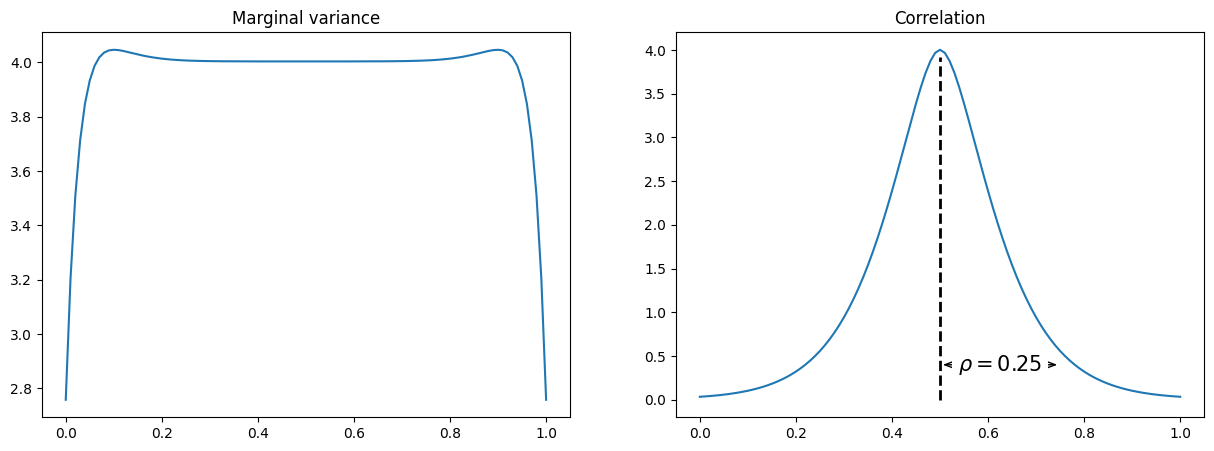

Prescribed marginal variance:  4
Actual marginal variance: 4.034133932273951


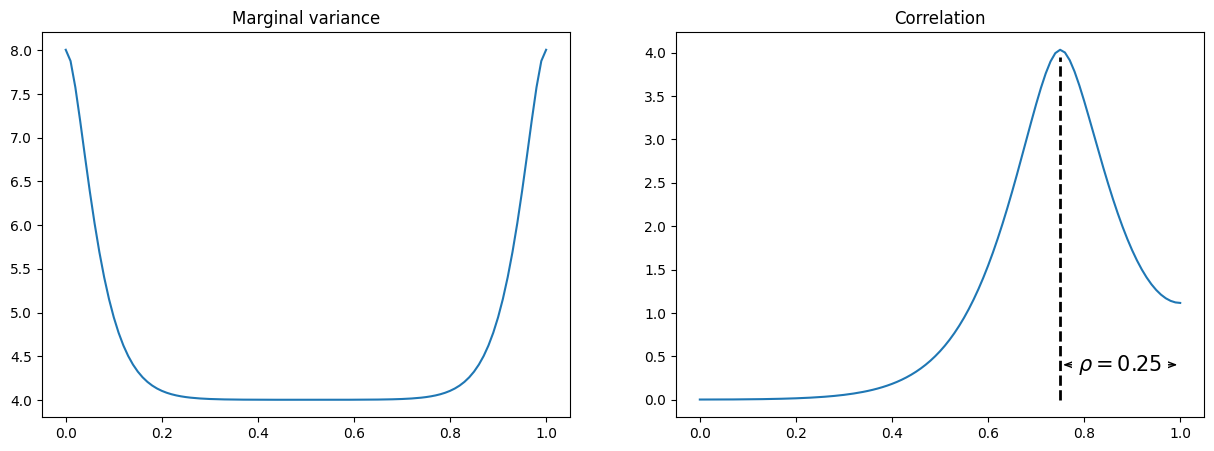

In [3]:
mesh = mfem.ParMesh(comm, mfem.Mesh.MakeCartesian1D(100, 1.0))
sigma2 = 4
rho = 0.25
coords = 0.5

makeCorrelationPlots(mesh, sigma2, rho, coords)

coords = 0.75

makeCorrelationPlots(mesh, sigma2, rho, coords, use_robin=False)

### The 2D case

Prescribed marginal variance:  4
Actual marginal variance: 3.98422011521004


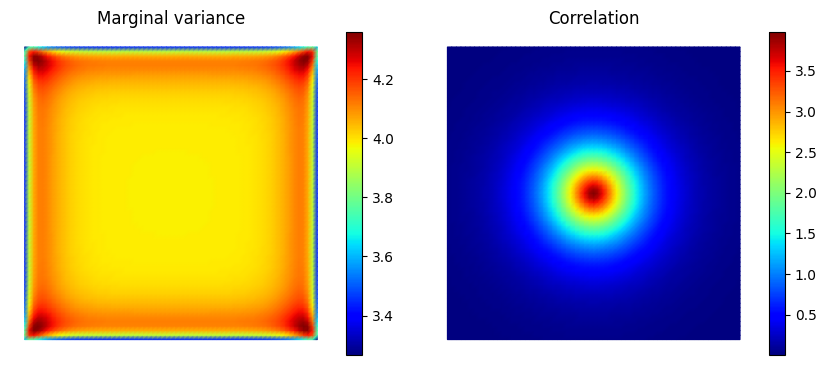

Prescribed marginal variance:  4
Actual marginal variance: 3.9964579488847014


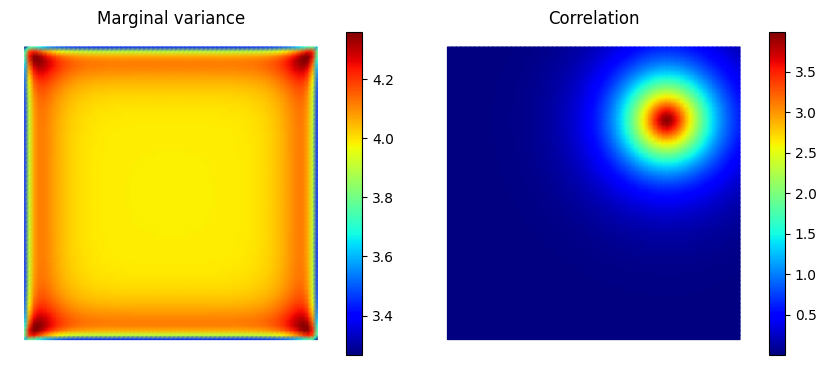

Prescribed marginal variance:  4
Actual marginal variance: 4.077372573874734


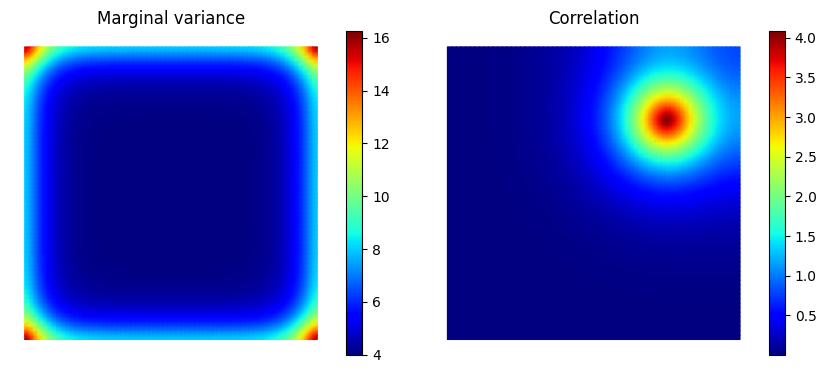

In [4]:
mesh = mfem.ParMesh(comm, mfem.Mesh.MakeCartesian2D(64, 64, mfem.Element.TRIANGLE))
sigma2 = 4
rho = 0.25
coords = (0.5, 0.5)

makeCorrelationPlots(mesh, sigma2, rho, coords, cmap="jet")

coords = (0.75, 0.75)
makeCorrelationPlots(mesh, sigma2, rho, coords, cmap="jet")

coords = (0.75, 0.75)
makeCorrelationPlots(mesh, sigma2, rho, coords, cmap="jet", use_robin=False)

## Generating Samples

A sample is the prior's square root applied to white noise: `sample_noise` draws the noise
element by element from a counter-based generator (so a sample is the same on any number of
MPI ranks), and `sample` solves with it.

In [5]:
def makeSamplePlots(mesh, sigma2, rho, degree=2, with_correlation=False, same_colorbar=True,
                    cmap=None, **kwargs):
    ndim = mesh.Dimension()
    Vh = hm.FunctionSpace.H1(mesh, 1)
    prior = make_prior(Vh, sigma2, rho, degree=degree, **kwargs)

    def sample(prior):
        noise = prior.noise_vector()
        prior.sample_noise(1.0, noise)
        s = Vh.vector()
        prior.sample(noise, s)
        return s

    plot_items = [(Vh, sample(prior)) for i in range(2)]
    labels = ["Sample 1", "Sample 2"]

    if with_correlation:
        center = tuple(ndim * [0.5])
        plot_items = [(Vh, correlationStructure(prior, Vh, center))] + plot_items
        labels = ["Correlation"] + labels

    nb.multi1_plot(plot_items, labels, same_colorbar=same_colorbar, cmap=cmap)
    plt.show()


hm.parRandom.set_seed(1)

### Isotropic samples

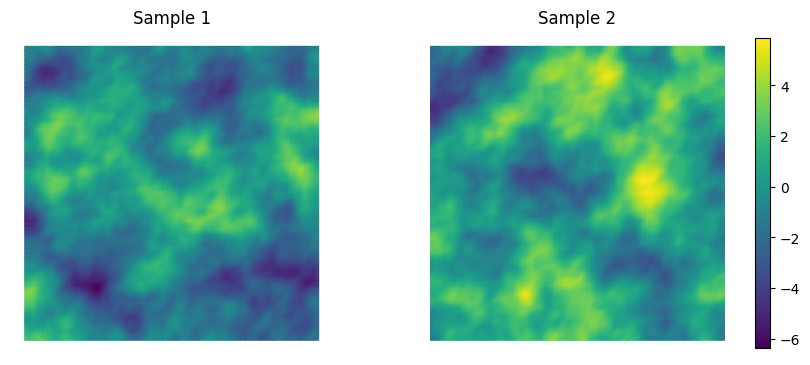

In [6]:
mesh = mfem.ParMesh(comm, mfem.Mesh.MakeCartesian2D(64, 64, mfem.Element.TRIANGLE))
sigma2 = 4
rho = 0.25
makeSamplePlots(mesh, sigma2, rho)

### Anisotropic samples with $\alpha = \frac{\pi}{4}$

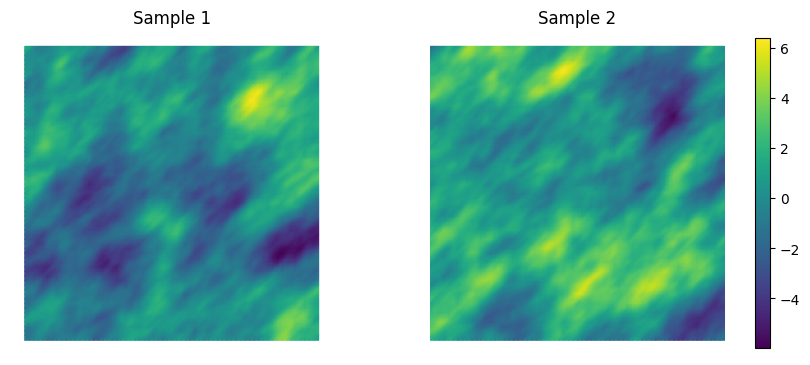

Prescribed marginal variance:  4
Actual marginal variance: 4.002680048624528


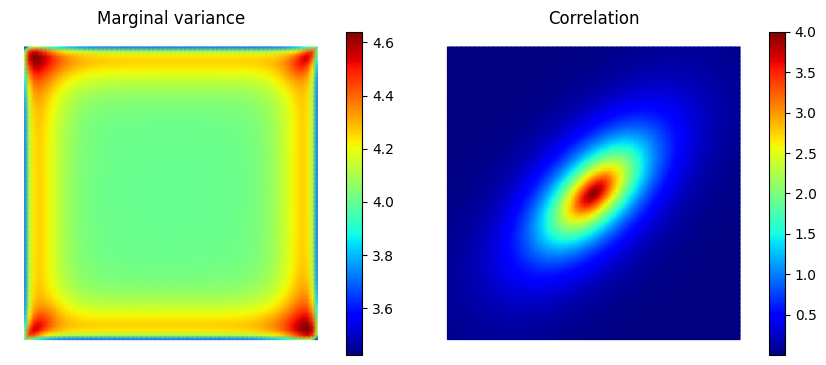

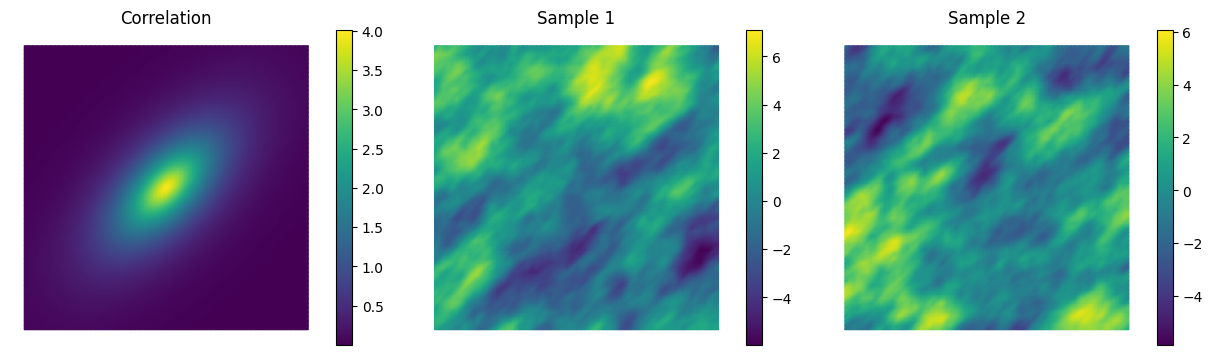

In [7]:
kwargs = {"theta0": 2.0, "theta1": 0.5, "alpha": math.pi / 4, "anisotropic": True}
makeSamplePlots(mesh, sigma2, rho, **kwargs)

coords = (0.5, 0.5)
makeCorrelationPlots(mesh, sigma2, rho, coords, cmap="jet", **kwargs)

makeSamplePlots(mesh, sigma2, rho, with_correlation=True, same_colorbar=False, **kwargs)

### Anisotropic samples with $\alpha = -\frac{\pi}{4}$

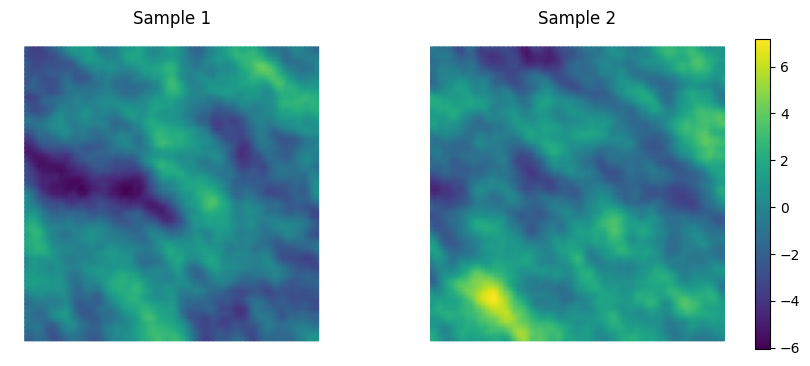

Prescribed marginal variance:  4
Actual marginal variance: 3.833567562702267


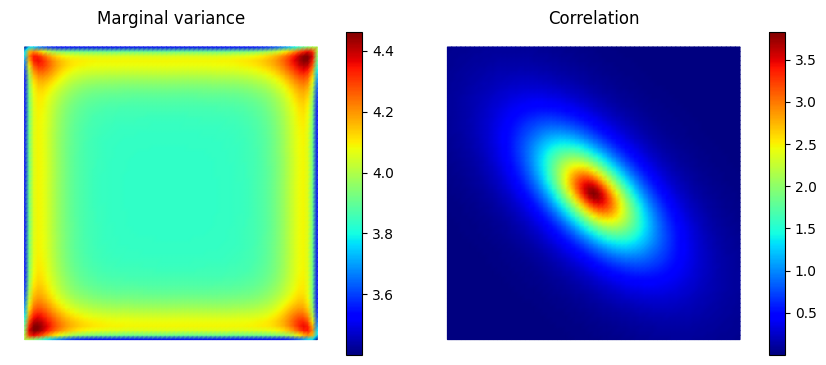

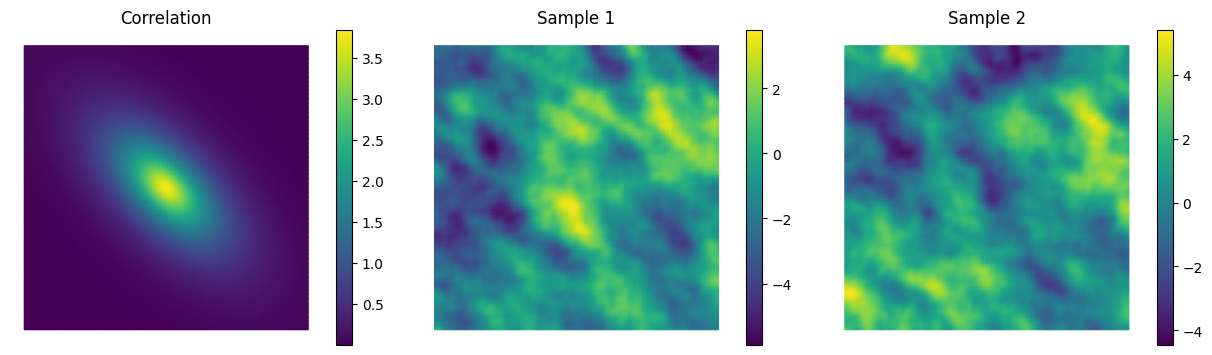

In [8]:
kwargs = {"theta0": 2.0, "theta1": 0.5, "alpha": -math.pi / 4, "anisotropic": True}
makeSamplePlots(mesh, sigma2, rho, **kwargs)

coords = (0.5, 0.5)
makeCorrelationPlots(mesh, sigma2, rho, coords, cmap="jet", **kwargs)

makeSamplePlots(mesh, sigma2, rho, with_correlation=True, same_colorbar=False, **kwargs)

## Mesh Dependence and Independence

A prior is a property of the continuous problem, so refining the mesh should not change it.
In two dimensions that holds for the BiLaplacian prior ($\alpha = 2 > d/2$) but not for the
Laplacian prior ($\alpha = 1 = d/2$), whose covariance is not trace class: its samples get
rougher and its pointwise variance grows as the mesh is refined, most visibly where the mesh
is refined locally.

The locally refined mesh bisects, four times, the triangles whose centroids lie in
$(0.2, 0.5) \times (0.3, 0.7)$; MFEM's conforming refinement keeps it free of hanging nodes.

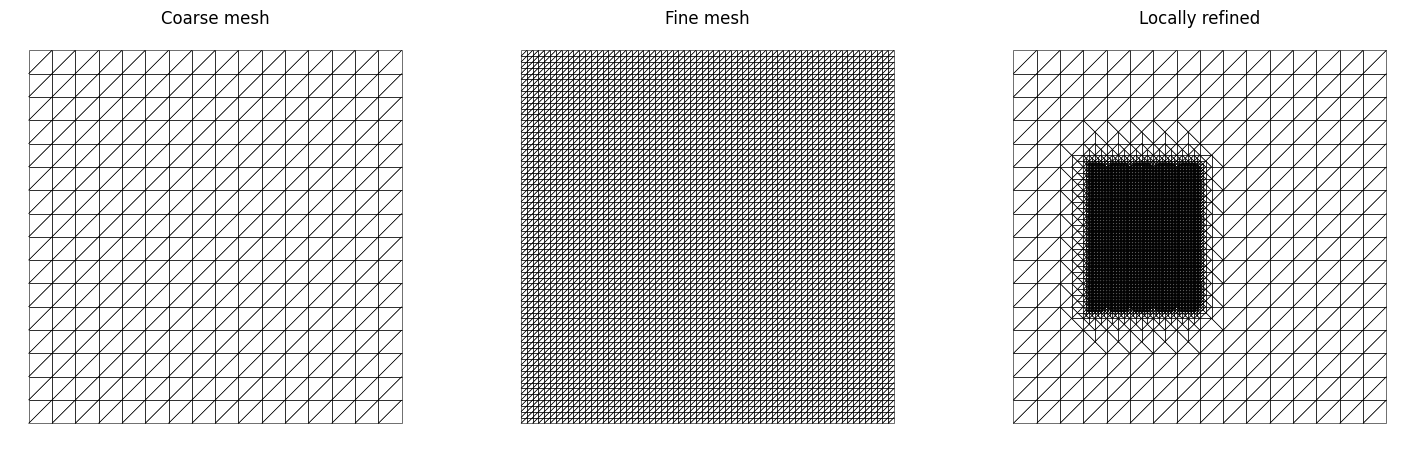

In [9]:
def locallyRefinedMesh():
    serial = mfem.Mesh.MakeCartesian2D(16, 16, mfem.Element.TRIANGLE)
    for _ in range(4):
        verts = np.asarray(serial.GetVertexArray(), dtype=float).reshape(serial.GetNV(), 2)
        marked = []
        for e in range(serial.GetNE()):
            c = verts[list(serial.GetElementVertices(e))].mean(axis=0)
            if 0.2 < c[0] < 0.5 and 0.3 < c[1] < 0.7:
                marked.append(e)
        serial.GeneralRefinement(mfem.intArray(marked), 0)
    return mfem.ParMesh(comm, serial)


mesh1 = mfem.ParMesh(comm, mfem.Mesh.MakeCartesian2D(16, 16, mfem.Element.TRIANGLE))
mesh2 = mfem.ParMesh(comm, mfem.Mesh.MakeCartesian2D(64, 64, mfem.Element.TRIANGLE))
mesh3 = locallyRefinedMesh()

plt.figure(figsize=(18, 6))
for i, (m, title) in enumerate(((mesh1, "Coarse mesh"), (mesh2, "Fine mesh"), (mesh3, "Locally refined"))):
    nb.plot(m, subplot_loc=131 + i, mytitle=title)
plt.show()

### Laplacian plots

#### coarse mesh


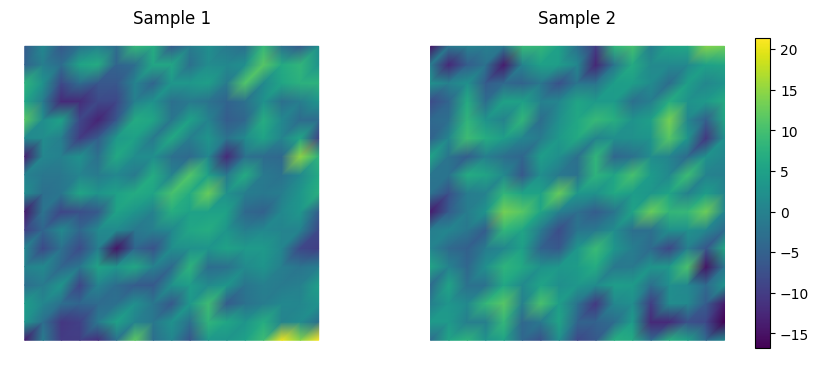

Prescribed marginal variance:  4
Actual marginal variance: 26.770020794493547


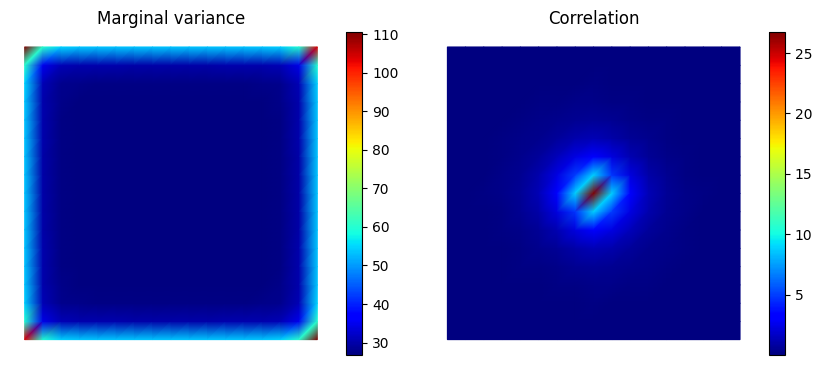

#### fine mesh


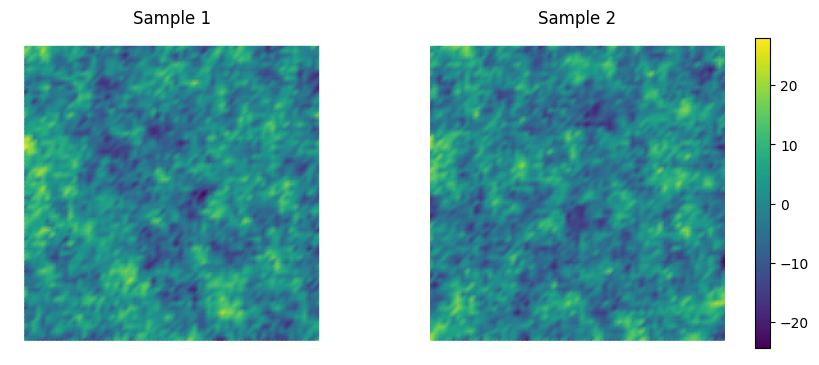

Prescribed marginal variance:  4
Actual marginal variance: 44.27759009876061


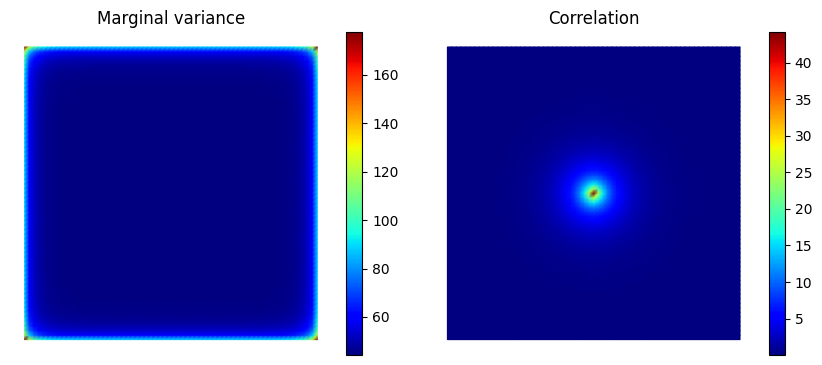

#### refined mesh


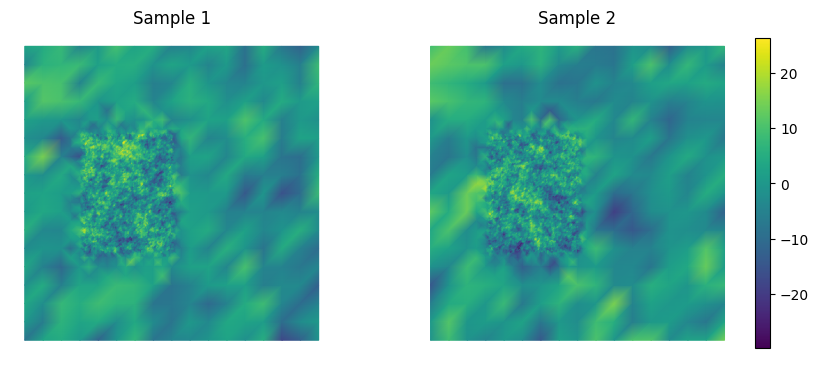

Prescribed marginal variance:  4
Actual marginal variance: 59.818487698341194


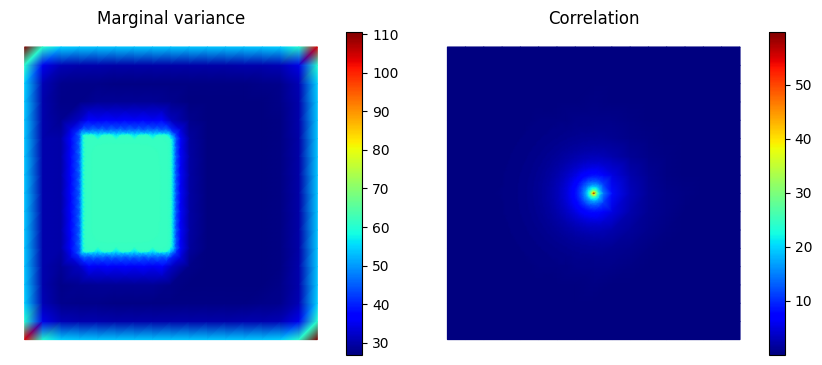

In [10]:
sigma2 = 4
rho = 0.25
coords = (0.5, 0.5)

meshes = {"coarse": mesh1, "fine": mesh2, "refined": mesh3}

for name, mesh in meshes.items():
    print("#### %s mesh" % name)
    makeSamplePlots(mesh, sigma2, rho, degree=1)
    makeCorrelationPlots(mesh, sigma2, rho, coords, degree=1, cmap="jet")

### BiLaplacian Plots

#### coarse mesh


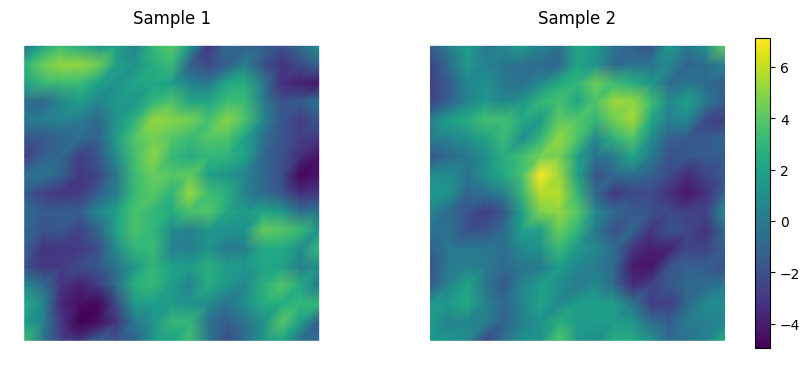

Prescribed marginal variance:  4
Actual marginal variance: 3.9152890106357536


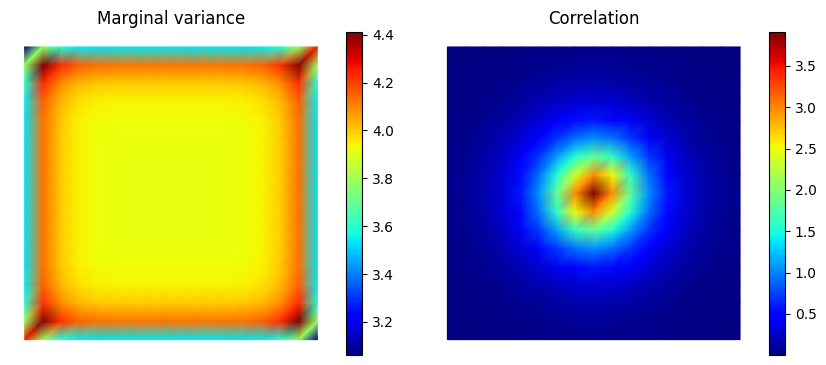

#### fine mesh


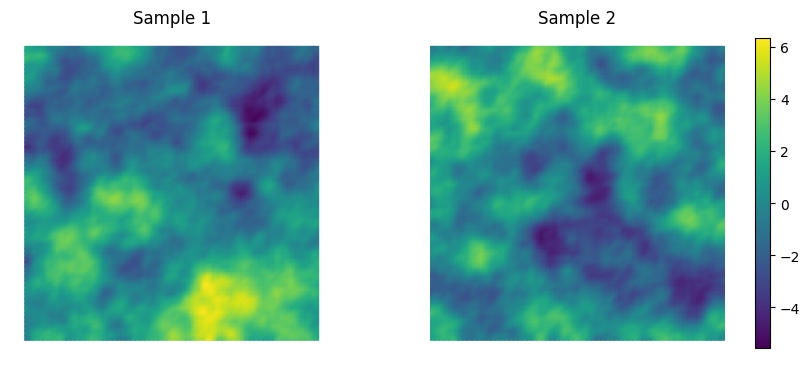

Prescribed marginal variance:  4
Actual marginal variance: 3.98422011521004


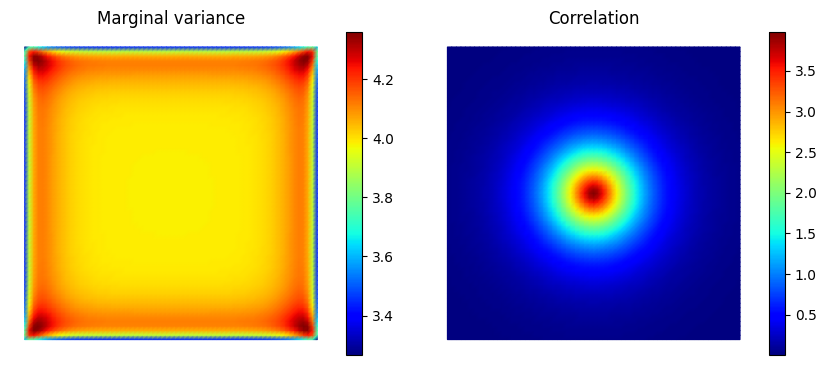

#### refined mesh


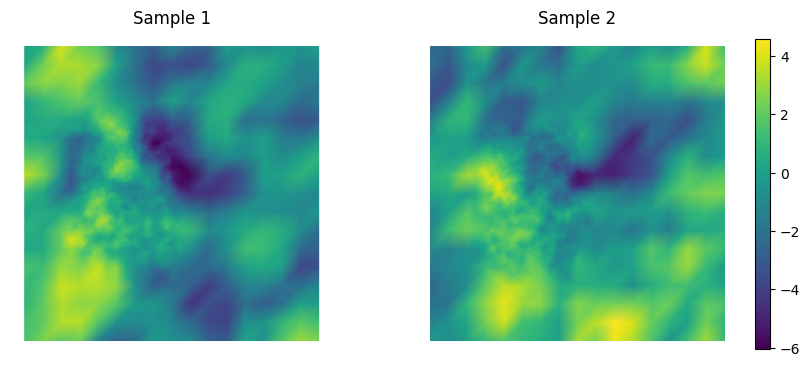

Prescribed marginal variance:  4
Actual marginal variance: 3.9118855544860858


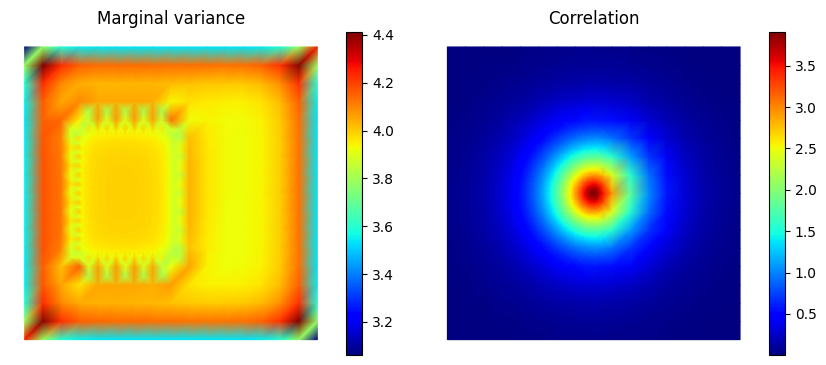

In [11]:
for name, mesh in meshes.items():
    print("#### %s mesh" % name)
    makeSamplePlots(mesh, sigma2, rho, degree=2)
    makeCorrelationPlots(mesh, sigma2, rho, coords, degree=2, cmap="jet")

*Adapted for hIPPyMFEM from hIPPYlib's tutorial `07_GaussianPriors`.*

Copyright (c) 2016-2018, The University of Texas at Austin & University of California, Merced.<br>
Copyright (c) 2019-2022, The University of Texas at Austin, University of California--Merced, Washington University in St. Louis.<br>
Copyright (c) 2023-, The University of Texas at Austin, University of California--Merced.<br>
Copyright (c) 2026, Peng Chen, Georgia Institute of Technology.<br>
See file COPYRIGHT for details.

This file is part of hIPPyMFEM, free software under the GNU General Public License
version 2.0 dated June 1991 (GPL-2.0-only). hIPPyMFEM follows the programming model
of [hIPPYlib](https://hippylib.github.io).